In [23]:
from ryp import r, to_py

import liesel_gam as gam


In [24]:
r("library(mgcv)")
r("data(columb)")
columb = to_py("columb", format="pandas")

In [25]:
from liesel_gam.term import Tf, Tx

In [26]:
tb = gam.TermBuilder.from_df(columb)

s = tb.ps(
    "x",
    k=5,
    absorb_cons=False,
    diagonal_penalty=False,
    scale_penalty=False,
)

sy = tb.ps(
    "y",
    k=5,
    absorb_cons=False,
    diagonal_penalty=False,
    scale_penalty=False,
)

tf = Tf(s, sy)

liesel.model.model - INFO - Unnamed variables and/or nodes were temporarily named.


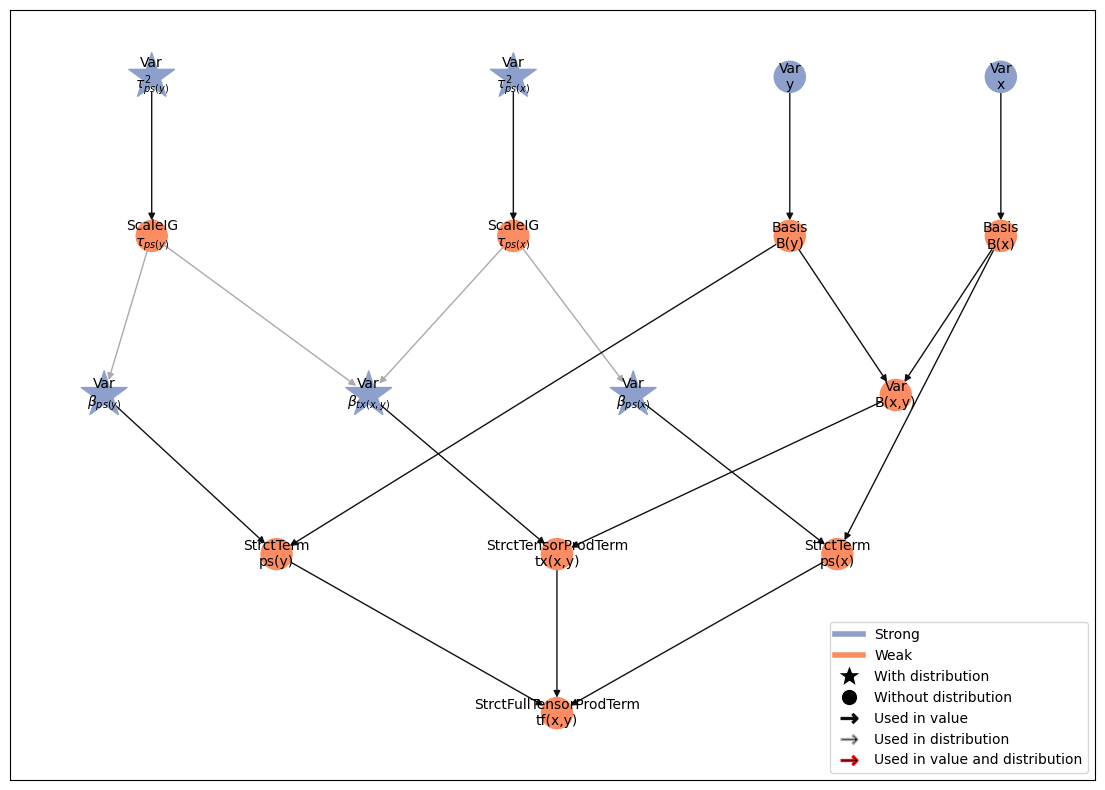

In [27]:
tf.plot_vars()

In [28]:
tb = gam.TermBuilder.from_df(columb)

s = tb.ps("x", k=5)
sy = tb.ps("y", k=5)
sz = tb.ps("area", k=5)

s.scale.value_node[0].inference = None
tf = Tf(s, sy, sz, group_terms_by_order=False, order=(1, 2))

liesel.model.model - INFO - Unnamed variables and/or nodes were temporarily named.


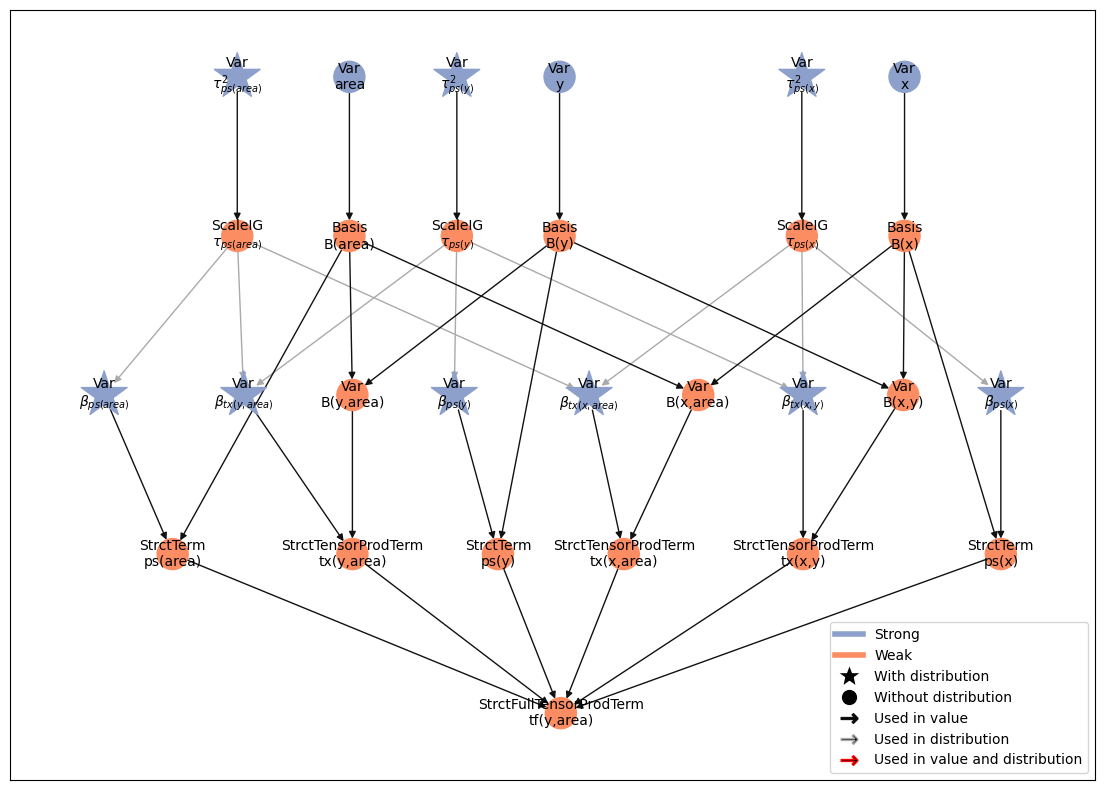

In [29]:
tf.plot_vars()